In [ ]:
!pip install qiskit qiskit-aer --quiet
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, entropy
import numpy as np


Step 1 | S(R) = 0.9938
Step 2 | S(R) = 1.9864
Step 3 | S(R) = 2.9752
Step 4 | S(R) = 3.9438
Step 5 | S(R) = 4.8107
Step 6 | S(R) = 5.2729
Step 7 | S(R) = 4.8107


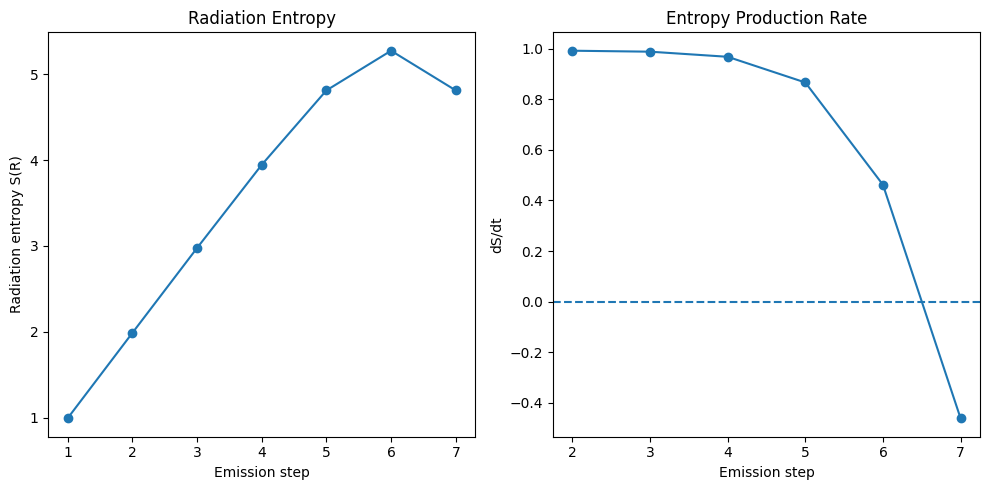

In [ ]:


# -----------------------------
# PARAMETERS
# -----------------------------

N_BH = 12      # black hole qubits
N_ENV = 4       # environment qubits (finite bath)
SCRAMBLE_DEPTH = 5

TOTAL_QUBITS = N_BH + N_ENV


# -----------------------------
# SCRAMBLING (chaotic dynamics)
# -----------------------------

def scramble_black_hole(qc, bh):
    """
    Chaotic fast-scrambling unitary.
    Mimics Haar random circuit using layered local + global entanglement.
    """

    LAYERS = 18   # try 15–20

    for _ in range(LAYERS):

        # --- random single-qubit rotations (local chaos) ---
        for q in bh:
            theta = np.random.uniform(0, 2*np.pi)
            phi   = np.random.uniform(0, 2*np.pi)
            lam   = np.random.uniform(0, 2*np.pi)
            qc.u(theta, phi, lam, q)

        # --- nearest-neighbour entanglement (local spreading) ---
        for i in range(len(bh)-1):
            qc.cx(bh[i], bh[i+1])

        # --- long-range entanglement (global scrambling) ---
        for i in range(len(bh)//2):
            qc.cz(bh[i], bh[-(i+1)])

        # --- random SWAP layer (operator growth) ---
        for i in range(0, len(bh)-1, 2):
            qc.swap(bh[i], bh[i+1])



# -----------------------------
# ENVIRONMENT DYNAMICS
# -----------------------------

def evolve_environment(qc, env):
    """Environment self-interaction (stores memory)"""
    if len(env) < 2:
        return

    for i in range(len(env)-1):
        qc.cx(env[i], env[i+1])
        qc.rx(np.pi/4, env[i])
        qc.ry(np.pi/7, env[i+1])


# -----------------------------
# BH-ENV COUPLING
# -----------------------------

def bh_environment_interaction(qc, bh, env):
    """Information exchange between system and bath"""
    for b in bh:
        for e in env:
            qc.cz(b, e)
            qc.rx(np.pi/8, b)
            qc.ry(np.pi/8, e)


# -----------------------------
# SIMULATION
# -----------------------------

def run_evaporation():

    qc = QuantumCircuit(TOTAL_QUBITS)
    state = Statevector.from_instruction(qc)

    bh = list(range(N_BH))
    env = list(range(N_BH, TOTAL_QUBITS))
    radiation = []

    entropies = []
    steps = []

    step = 0

    while len(bh) > 1:

        step += 1

        # 1. BH scrambling
        scramble_black_hole(qc, bh)

        # 2. environment evolves
        evolve_environment(qc, env)

        # 3. BH <-> environment interaction
        bh_environment_interaction(qc, bh, env)

        # update global state
        state = Statevector.from_instruction(qc)

        # 4. emission
        emitted = bh.pop(0)
        radiation.append(emitted)

        # 5. compute radiation entropy
        trace_out = bh + env
        rho_R = partial_trace(state, trace_out)
        S_R = entropy(rho_R, base=2)

        entropies.append(S_R)
        steps.append(step)

        print(f"Step {step} | S(R) = {S_R:.4f}")

    return steps, entropies


# -----------------------------
# MAIN
# -----------------------------

if __name__ == "__main__":

    steps, entropy_R = run_evaporation()

    # entropy production rate
    dS = np.diff(entropy_R)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.plot(steps, entropy_R, 'o-')
    plt.xlabel("Emission step")
    plt.ylabel("Radiation entropy S(R)")
    plt.title("Radiation Entropy")

    plt.subplot(1,2,2)
    plt.plot(steps[1:], dS, 'o-')
    plt.axhline(0, linestyle='--')
    plt.xlabel("Emission step")
    plt.ylabel("dS/dt")
    plt.title("Entropy Production Rate")

    plt.tight_layout()
    plt.show()
